<a href="https://colab.research.google.com/github/Akhilcoe/Clustering/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing different clustering algorithms for different Preprocessing techniques

## Importing Libraries (We will be primarily using pycaret)

In [1]:
import pycaret
import pandas as pd

from pycaret.utils import version
version()

'3.3.2'

## Viewing available dataset in ucl Library

In [2]:
from pycaret.datasets import get_data
get_data('index') ## Here we have a total of 56 datasets

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


## Importing Dataset (we will be using "seeds",SN:37 dataset)

In [3]:
dataset=get_data("seeds")

,area,perimeter,compactness,length,width,asymmetry,length.1
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Saving and downloading dataset

In [4]:
dataset.to_csv("seeds.csv")

## Parameter setting for clustering models

In [5]:
from pycaret.clustering import *
s=setup(dataset,session_id=28)

,Description,Value
0,Session id,28
1,Original data shape,"(210, 7)"
2,Transformed data shape,"(210, 7)"
3,Numeric features,7
4,Rows with missing values,1.4%
5,Preprocess,True
6,Imputation type,simple
7,Numeric imputation,mean
8,Categorical imputation,mode
9,CPU Jobs,-1


In [6]:
## All available clustering models in pycaret
models()
## We will be using four algorithms: kmeans, hclust, spectral and birch

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch


## Understanding basic operations for pycaret clustering

### Building a clustering model (here using kmeans)

In [7]:
Kmeanmodel=create_model('kmeans',num_clusters=4)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3909,275.0454,0.9340,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

### Assigning clusters using trained model

In [8]:
Kmeanpredictions=assign_model(Kmeanmodel)
Kmeanpredictions

,area,perimeter,compactness,length,width,asymmetry,length.1,Cluster
0,15.260000,14.84,0.8710,5.763,3.312,2.221,5.220,Cluster 2
1,14.880000,14.57,0.8811,5.554,3.333,1.018,4.956,Cluster 2
2,14.290000,14.09,0.9050,5.291,3.337,2.699,4.825,Cluster 2
3,13.840000,13.94,0.8955,5.324,3.379,2.259,4.805,Cluster 2
4,16.139999,14.99,0.9034,5.658,3.562,1.355,5.175,Cluster 2
...,...,...,...,...,...,...,...,...
205,12.190000,13.20,0.8783,5.137,2.981,3.631,4.870,Cluster 0
206,11.230000,12.88,0.8511,5.140,2.795,4.325,5.003,Cluster 3
207,13.200000,13.66,0.8883,5.236,3.232,8.315,5.056,Cluster 3
208,11.840000,13.21,0.8521,5.175,2.836,3.598,5.044,Cluster 0


### Evaluating models using graphs

In [9]:
evaluate_model(Kmeanmodel)  ## This function usually limited to notebook

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [10]:
plot_model(Kmeanmodel,plot='cluster')

In [11]:
plot_model(Kmeanmodel,plot='tsne')

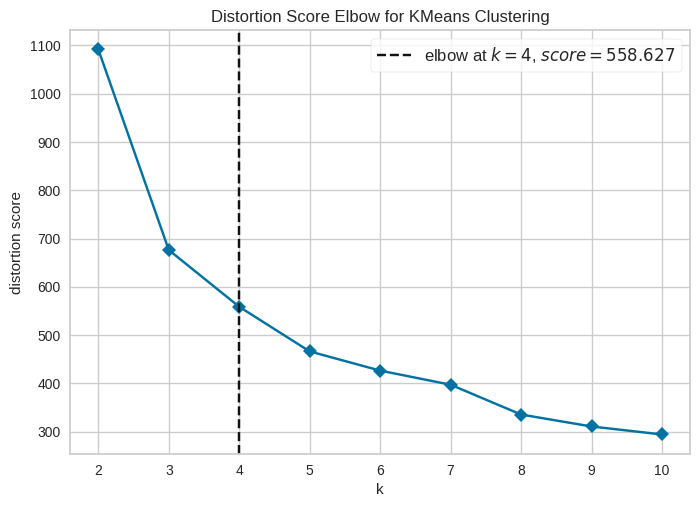

In [12]:
plot_model(Kmeanmodel,plot='elbow')

In [13]:
plot_model(Kmeanmodel,plot='distribution')

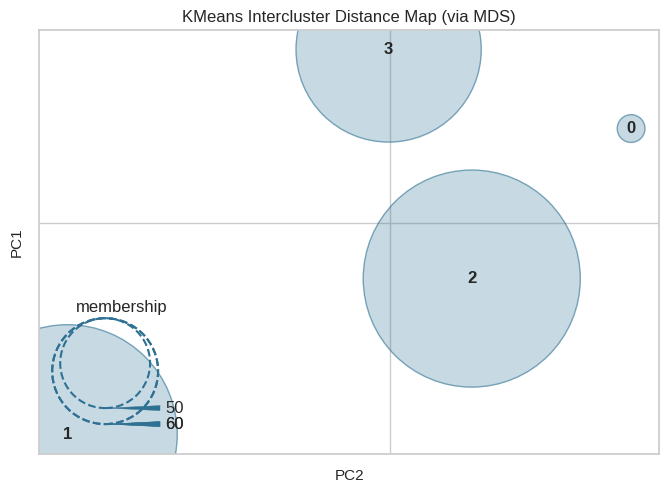

In [14]:
plot_model(Kmeanmodel,plot='distance')

## Comparison

### Using Kmeans clustering algorithm

#### No data Preprocessing

In [15]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,verbose=False)

print("For Cluster=3")
x=create_model('kmeans',num_clusters=3)

print("For Cluster=4")
x=create_model('kmeans',num_clusters=4)

print("For Cluster=5")
x=create_model('kmeans',num_clusters=5)

print("For Cluster=6")
x=create_model('kmeans',num_clusters=6)


For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5839,823.2363,0.5039,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5535,993.8793,0.5181,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5393,1184.7512,0.5195,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5321,1378.4050,0.5173,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [16]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Normalization

In [17]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',verbose=False)

print("For Cluster=3")
x=create_model('kmeans',num_clusters=3)

print("For Cluster=4")
x=create_model('kmeans',num_clusters=4)

print("For Cluster=5")
x=create_model('kmeans',num_clusters=5)

print("For Cluster=6")
x=create_model('kmeans',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4444,163.9681,0.9168,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4536,167.0381,0.7913,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3657,143.9556,1.0415,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3028,125.4486,1.2683,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [18]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation

In [19]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('kmeans',num_clusters=3)

print("For Cluster=4")
x=create_model('kmeans',num_clusters=4)

print("For Cluster=5")
x=create_model('kmeans',num_clusters=5)

print("For Cluster=6")
x=create_model('kmeans',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5232,492.8698,0.5665,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5215,616.6220,0.5385,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5084,726.7614,0.5553,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4687,728.7273,0.5873,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [20]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using PCA

In [21]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('kmeans',num_clusters=3)

print("For Cluster=4")
x=create_model('kmeans',num_clusters=4)

print("For Cluster=5")
x=create_model('kmeans',num_clusters=5)

print("For Cluster=6")
x=create_model('kmeans',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5839,823.2363,0.5039,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5535,993.8793,0.5181,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5393,1184.8815,0.5198,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5301,1369.3617,0.5187,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization

In [23]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('kmeans',num_clusters=3)

print("For Cluster=4")
x=create_model('kmeans',num_clusters=4)

print("For Cluster=5")
x=create_model('kmeans',num_clusters=5)

print("For Cluster=6")
x=create_model('kmeans',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4370,199.6873,0.8853,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4440,151.1280,0.8411,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3519,128.2845,1.1538,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2570,111.0554,1.3659,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [24]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization + PCA

In [25]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('kmeans',num_clusters=3)

print("For Cluster=4")
x=create_model('kmeans',num_clusters=4)

print("For Cluster=5")
x=create_model('kmeans',num_clusters=5)

print("For Cluster=6")
x=create_model('kmeans',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4415,199.3507,0.9076,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3756,152.4577,1.2335,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3686,128.6378,1.0990,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2976,116.2411,1.3281,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [26]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [27]:
data = {
    ("No Data Processing", "c=3"): [0.4540, 324.4954, 0.7987],
    ("No Data Processing", "c=4"): [0.3909, 275.0454, 0.9340],
    ("No Data Processing", "c=5"): [0.3788, 230.2999, 0.9438],
    ("No Data Processing", "c=6"): [0.3375, 215.0900, 1.0268],

    ("Using Normalization", "c=3"): [0.3842, 155.4342, 1.0274],
    ("Using Normalization", "c=4"): [0.3011, 119.3509, 1.1413],
    ("Using Normalization", "c=5"): [0.3039, 138.0138, 1.1575],
    ("Using Normalization", "c=6"): [0.2328, 125.5648, 1.3058],

    ("Using Transform", "c=3"): [0.5161, 492.7559, 0.5731],
    ("Using Transform", "c=4"): [0.5219, 616.7174, 0.5381],
    ("Using Transform", "c=5"): [0.5178, 732.8043, 0.5552],
    ("Using Transform", "c=6"): [0.5044, 783.4492, 0.5682],

    ("Using PCA", "c=3"): [0.4572,324.3747,0.7981],
    ("Using PCA", "c=4"): [0.3832,271.1957,0.9293],
    ("Using PCA", "c=5"): [0.3701,256.4964,0.9549],
    ("Using PCA", "c=6"): [0.3497,223.8657,0.9696],

    ("Using T+N", "c=3"): [0.3929,195.8647,0.9932],
    ("Using T+N", "c=4"): [0.3071,152.1490,1.1609],
    ("Using T+N", "c=5"): [0.2563,130.5739,1.3199],
    ("Using T+N", "c=6"): [0.2469,117.2666,1.3072],

    ("T+N+PCA", "c=3"): [0.3960,196.5351,0.9848],
    ("T+N+PCA", "c=4"): [0.3022,145.0075,1.3367],
    ("T+N+PCA", "c=5"): [0.2582,125.9156,1.4875],
    ("T+N+PCA", "c=6"): [0.2555,112.2360,1.2353],
}


df1 = pd.DataFrame(data, index=["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])

latex_table = f"""
\\begin{{table}}[h]
    \\centering
    \\caption{{Using K-Means Clustering}}
    {df1.to_latex(index=True, multirow=True, escape=False)}
\\end{{table}}
"""

with open("kmeans_table.tex", "w") as f:
    f.write(latex_table)

df1

No Data Processing                                \
                                 c=3       c=4       c=5       c=6   
Silhouette                    0.4540    0.3909    0.3788    0.3375   
Calinski-Harabasz           324.4954  275.0454  230.2999  215.0900   
Davies-Bouldin                0.7987    0.9340    0.9438    1.0268   

                  Using Normalization                                \
                                  c=3       c=4       c=5       c=6   
Silhouette                     0.3842    0.3011    0.3039    0.2328   
Calinski-Harabasz            155.4342  119.3509  138.0138  125.5648   
Davies-Bouldin                 1.0274    1.1413    1.1575    1.3058   

                  Using Transform            ... Using PCA            \
                              c=3       c=4  ...       c=5       c=6   
Silhouette                 0.5161    0.5219  ...    0.3701    0.3497   
Calinski-Harabasz        492.7559  616.7174  ...  256.4964  223.8657   
Davies-Bouldin             0.5731    0.5381  ...    0.9549    0.9696   

                  Using T+N                                 T+N+PCA            \
                        c=3       c=4       c=5       c=6       c=3       c=4   
Silhouette           0.3929    0.3071    0.2563    0.2469    0.3960    0.3022   
Calinski-Harabasz  195.8647  152.1490  130.5739  117.2666  196.5351  145.0075   
Davies-Bouldin       0.9932    1.1609    1.3199    1.3072    0.9848    1.3367   

                                       
                        c=5       c=6  
Silhouette           0.2582    0.2555  
Calinski-Harabasz  125.9156  112.2360  
Davies-Bouldin       1.4875    1.2353  

[3 rows x 24 columns]

### Using Agglomerative clustering algorithm (hclust)

#### No data Preprocessing

In [28]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,verbose=False)

print("For Cluster=3")
x=create_model('hclust',num_clusters=3)

print("For Cluster=4")
x=create_model('hclust',num_clusters=4)

print("For Cluster=5")
x=create_model('hclust',num_clusters=5)

print("For Cluster=6")
x=create_model('hclust',num_clusters=6)


For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5380,714.0647,0.5047,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5341,781.6367,0.5175,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5311,1154.1034,0.5196,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5093,1177.2100,0.5238,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [29]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Normalization

In [30]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',verbose=False)

print("For Cluster=3")
x=create_model('hclust',num_clusters=3)

print("For Cluster=4")
x=create_model('hclust',num_clusters=4)

print("For Cluster=5")
x=create_model('hclust',num_clusters=5)

print("For Cluster=6")
x=create_model('hclust',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4395,161.9026,0.9158,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4507,165.1487,0.7977,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3524,138.9631,0.9787,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2649,125.1565,1.1593,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [31]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation

In [32]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('hclust',num_clusters=3)

print("For Cluster=4")
x=create_model('hclust',num_clusters=4)

print("For Cluster=5")
x=create_model('hclust',num_clusters=5)

print("For Cluster=6")
x=create_model('hclust',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5286,486.7078,0.5609,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4968,484.6721,0.5261,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4851,625.1704,0.5546,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4777,671.9193,0.5676,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [33]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using PCA

In [34]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('hclust',num_clusters=3)

print("For Cluster=4")
x=create_model('hclust',num_clusters=4)

print("For Cluster=5")
x=create_model('hclust',num_clusters=5)

print("For Cluster=6")
x=create_model('hclust',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5380,714.0647,0.5047,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5341,781.6367,0.5175,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5311,1154.1034,0.5196,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5093,1177.2100,0.5238,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [35]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization

In [36]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('hclust',num_clusters=3)

print("For Cluster=4")
x=create_model('hclust',num_clusters=4)

print("For Cluster=5")
x=create_model('hclust',num_clusters=5)

print("For Cluster=6")
x=create_model('hclust',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4396,197.7073,0.9045,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4443,152.6972,1.0793,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3566,128.4011,1.1764,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3047,115.1475,1.2820,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [37]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization + PCA

In [38]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('hclust',num_clusters=3)

print("For Cluster=4")
x=create_model('hclust',num_clusters=4)

print("For Cluster=5")
x=create_model('hclust',num_clusters=5)

print("For Cluster=6")
x=create_model('hclust',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4396,197.7073,0.9045,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4443,152.6972,1.0793,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3566,128.4011,1.1764,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3047,115.1475,1.2820,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [39]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [40]:
data = {
    ("No Data Processing", "c=3"): [0.5380,714.0647,0.5047],
    ("No Data Processing", "c=4"): [0.5341,781.6367,0.5175],
    ("No Data Processing", "c=5"): [0.5311,1154.1034,0.5196],
    ("No Data Processing", "c=6"): [0.5093,1177.2100,0.5238],

    ("Using Normalization", "c=3"): [0.4395,161.9026,0.9158],
    ("Using Normalization", "c=4"): [0.4507,165.1487,0.7977],
    ("Using Normalization", "c=5"): [0.3524,138.9631,0.9787],
    ("Using Normalization", "c=6"): [0.2649,125.1565,1.1593],

    ("Using Transform", "c=3"): [0.5286,486.7078,0.5609],
    ("Using Transform", "c=4"): [0.4968,484.6721,0.5261],
    ("Using Transform", "c=5"): [0.4851,625.1704,0.5546],
    ("Using Transform", "c=6"): [0.4777,671.9193,0.5676],

    ("Using PCA", "c=3"): [0.5380,714.0647,0.5047],
    ("Using PCA", "c=4"): [0.5341,781.6367,0.5175],
    ("Using PCA", "c=5"): [0.5311,1154.1034,0.5196],
    ("Using PCA", "c=6"): [0.5093,1177.2100,0.5238],

    ("Using T+N", "c=3"): [0.4396,197.7073,0.9045],
    ("Using T+N", "c=4"): [0.4443,152.6972,1.0793],
    ("Using T+N", "c=5"): [0.3566,128.4011,1.1764],
    ("Using T+N", "c=6"): [0.3047,115.1475,1.2820],

    ("T+N+PCA", "c=3"): [0.4396,197.7073,0.9045],
    ("T+N+PCA", "c=4"): [0.4443,152.6972,1.0793],
    ("T+N+PCA", "c=5"): [0.3566,128.4011,1.1764],
    ("T+N+PCA", "c=6"): [0.3047,115.1475,1.2820],
}


df2 = pd.DataFrame(data, index=["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])

latex_table = f"""
\\begin{{table}}[h]
    \\centering
    \\caption{{Using K-Means Clustering}}
    {df2.to_latex(index=True, multirow=True, escape=False)}
\\end{{table}}
"""

with open("hclust_table.tex", "w") as f:
    f.write(latex_table)

df2

No Data Processing                                  \
                                 c=3       c=4        c=5        c=6   
Silhouette                    0.5380    0.5341     0.5311     0.5093   
Calinski-Harabasz           714.0647  781.6367  1154.1034  1177.2100   
Davies-Bouldin                0.5047    0.5175     0.5196     0.5238   

                  Using Normalization                                \
                                  c=3       c=4       c=5       c=6   
Silhouette                     0.4395    0.4507    0.3524    0.2649   
Calinski-Harabasz            161.9026  165.1487  138.9631  125.1565   
Davies-Bouldin                 0.9158    0.7977    0.9787    1.1593   

                  Using Transform            ...  Using PCA             \
                              c=3       c=4  ...        c=5        c=6   
Silhouette                 0.5286    0.4968  ...     0.5311     0.5093   
Calinski-Harabasz        486.7078  484.6721  ...  1154.1034  1177.2100   
Davies-Bouldin             0.5609    0.5261  ...     0.5196     0.5238   

                  Using T+N                                 T+N+PCA            \
                        c=3       c=4       c=5       c=6       c=3       c=4   
Silhouette           0.4396    0.4443    0.3566    0.3047    0.4396    0.4443   
Calinski-Harabasz  197.7073  152.6972  128.4011  115.1475  197.7073  152.6972   
Davies-Bouldin       0.9045    1.0793    1.1764    1.2820    0.9045    1.0793   

                                       
                        c=5       c=6  
Silhouette           0.3566    0.3047  
Calinski-Harabasz  128.4011  115.1475  
Davies-Bouldin       1.1764    1.2820  

[3 rows x 24 columns]

### Using Birch clustering algorithm (birch)

#### No data Preprocessing

In [41]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,verbose=False)

print("For Cluster=3")
x=create_model('birch',num_clusters=3)

print("For Cluster=4")
x=create_model('birch',num_clusters=4)

print("For Cluster=5")
x=create_model('birch',num_clusters=5)

print("For Cluster=6")
x=create_model('birch',num_clusters=6)


For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5380,714.0647,0.5047,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5341,781.6367,0.5175,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5311,1154.1034,0.5196,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5093,1177.2100,0.5238,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [42]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Normalization

In [43]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',verbose=False)

print("For Cluster=3")
x=create_model('birch',num_clusters=3)

print("For Cluster=4")
x=create_model('birch',num_clusters=4)

print("For Cluster=5")
x=create_model('birch',num_clusters=5)

print("For Cluster=6")
x=create_model('birch',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3917,144.7153,0.9699,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4130,146.4943,0.8552,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3724,132.5521,1.0643,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3712,116.4719,0.9276,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [44]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation

In [45]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('birch',num_clusters=3)

print("For Cluster=4")
x=create_model('birch',num_clusters=4)

print("For Cluster=5")
x=create_model('birch',num_clusters=5)

print("For Cluster=6")
x=create_model('birch',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5286,486.7078,0.5609,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4968,484.6721,0.5261,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4851,625.1704,0.5546,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4777,671.9193,0.5676,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [46]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using PCA

In [47]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('birch',num_clusters=3)

print("For Cluster=4")
x=create_model('birch',num_clusters=4)

print("For Cluster=5")
x=create_model('birch',num_clusters=5)

print("For Cluster=6")
x=create_model('birch',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5380,714.0647,0.5047,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5341,781.6367,0.5175,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5311,1154.1034,0.5196,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5093,1177.2100,0.5238,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [48]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization

In [49]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('birch',num_clusters=3)

print("For Cluster=4")
x=create_model('birch',num_clusters=4)

print("For Cluster=5")
x=create_model('birch',num_clusters=5)

print("For Cluster=6")
x=create_model('birch',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4243,188.0415,0.9314,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4118,148.1406,1.4157,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3723,123.0400,1.2173,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3749,107.0929,0.9953,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [50]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization + PCA

In [51]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('birch',num_clusters=3)

print("For Cluster=4")
x=create_model('birch',num_clusters=4)

print("For Cluster=5")
x=create_model('birch',num_clusters=5)

print("For Cluster=6")
x=create_model('birch',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4243,188.0415,0.9314,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4118,148.1406,1.4157,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3723,123.0400,1.2173,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3749,107.0929,0.9953,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [52]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [53]:
data = {
    ("No Data Processing", "c=3"): [0.5282,659.6653,0.5033],
    ("No Data Processing", "c=4"): [0.5480,904.8047,0.5091],
    ("No Data Processing", "c=5"): [0.5289,1123.6178,0.5097],
    ("No Data Processing", "c=6"): [0.4882,1114.3060,0.5162],

    ("Using Normalization", "c=3"): [0.4720,181.4853,0.7999],
    ("Using Normalization", "c=4"): [0.4934,180.8686,0.7652],
    ("Using Normalization", "c=5"): [0.4926,147.8058,0.6521],
    ("Using Normalization", "c=6"): [0.3778,133.6411,0.8838],

    ("Using Transform", "c=3"): [0.5058,438.5621,0.5317],
    ("Using Transform", "c=4"): [0.5116,607.4622,0.5520],
    ("Using Transform", "c=5"): [0.4979,629.0359,0.5348],
    ("Using Transform", "c=6"): [0.4884,677.2758,0.5518],

    ("Using PCA", "c=3"): [0.5282,659.6653,0.5033],
    ("Using PCA", "c=4"): [0.5480,904.8047,0.5091],
    ("Using PCA", "c=5"): [0.5289,1123.6178,0.5097],
    ("Using PCA", "c=6"): [0.4882,1114.3060,0.5162],

    ("Using T+N", "c=3"): [0.4725,214.2713,0.8250],
    ("Using T+N", "c=4"): [0.4828,165.5473,1.0653],
    ("Using T+N", "c=5"): [0.4849,134.0345,0.7287],
    ("Using T+N", "c=6"): [0.3977,116.3283,0.9356],

    ("T+N+PCA", "c=3"): [0.4725,214.2713,0.8250],
    ("T+N+PCA", "c=4"): [0.4828,165.5473,1.0653],
    ("T+N+PCA", "c=5"): [0.4849,134.0345,0.7287],
    ("T+N+PCA", "c=6"): [0.3977,116.3283,0.9356],
}


df3 = pd.DataFrame(data, index=["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])

latex_table = f"""
\\begin{{table}}[h]
    \\centering
    \\caption{{Using K-Means Clustering}}
    {df3.to_latex(index=True, multirow=True, escape=False)}
\\end{{table}}
"""

with open("birch_table.tex", "w") as f:
    f.write(latex_table)

df3

No Data Processing                                  \
                                 c=3       c=4        c=5        c=6   
Silhouette                    0.5282    0.5480     0.5289     0.4882   
Calinski-Harabasz           659.6653  904.8047  1123.6178  1114.3060   
Davies-Bouldin                0.5033    0.5091     0.5097     0.5162   

                  Using Normalization                                \
                                  c=3       c=4       c=5       c=6   
Silhouette                     0.4720    0.4934    0.4926    0.3778   
Calinski-Harabasz            181.4853  180.8686  147.8058  133.6411   
Davies-Bouldin                 0.7999    0.7652    0.6521    0.8838   

                  Using Transform            ...  Using PCA             \
                              c=3       c=4  ...        c=5        c=6   
Silhouette                 0.5058    0.5116  ...     0.5289     0.4882   
Calinski-Harabasz        438.5621  607.4622  ...  1123.6178  1114.3060   
Davies-Bouldin             0.5317    0.5520  ...     0.5097     0.5162   

                  Using T+N                                 T+N+PCA            \
                        c=3       c=4       c=5       c=6       c=3       c=4   
Silhouette           0.4725    0.4828    0.4849    0.3977    0.4725    0.4828   
Calinski-Harabasz  214.2713  165.5473  134.0345  116.3283  214.2713  165.5473   
Davies-Bouldin       0.8250    1.0653    0.7287    0.9356    0.8250    1.0653   

                                       
                        c=5       c=6  
Silhouette           0.4849    0.3977  
Calinski-Harabasz  134.0345  116.3283  
Davies-Bouldin       0.7287    0.9356  

[3 rows x 24 columns]

### Using Spectral clustering algorithm

#### No data Preprocessing

In [54]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,verbose=False)

print("For Cluster=3")
x=create_model('sc',num_clusters=3)

print("For Cluster=4")
x=create_model('sc',num_clusters=4)

print("For Cluster=5")
x=create_model('sc',num_clusters=5)

print("For Cluster=6")
x=create_model('sc',num_clusters=6)


For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.5070,1.8246,0.8050,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.4279,21.2767,1.4791,0,0,0


...

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.2133,8.7860,3.7616,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.0598,203.7343,1.1699,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [55]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Normalization

In [ ]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',verbose=False)

print("For Cluster=3")
x=create_model('sc',num_clusters=3)

print("For Cluster=4")
x=create_model('sc',num_clusters=4)

print("For Cluster=5")
x=create_model('sc',num_clusters=5)

print("For Cluster=6")
x=create_model('sc',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4582,8.4782,0.6350,0,0,0


For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3823,53.9896,0.7544,0,0,0


For Cluster=5


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2331,42.6089,0.7521,0,0,0


For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.0696,34.1317,2.4339,0,0,0


In [ ]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation

In [ ]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('sc',num_clusters=3)

print("For Cluster=4")
x=create_model('sc',num_clusters=4)

print("For Cluster=5")
x=create_model('sc',num_clusters=5)

print("For Cluster=6")
x=create_model('sc',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0,0,0,0,0,0


For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0,0,0,0,0,0


For Cluster=5


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0,0,0,0,0,0


For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0,0,0,0,0,0


In [ ]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using PCA

In [ ]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('sc',num_clusters=3)

print("For Cluster=4")
x=create_model('sc',num_clusters=4)

print("For Cluster=5")
x=create_model('sc',num_clusters=5)

print("For Cluster=6")
x=create_model('sc',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.0821,2.0801,3.6493,0,0,0


For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.5171,3.2881,0.7112,0,0,0


For Cluster=5


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.5045,3.8829,0.6992,0,0,0


For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,-0.5153,3.4544,3.0452,0,0,0


In [ ]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization

In [ ]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',verbose=False)

print("For Cluster=3")
x=create_model('sc',num_clusters=3)

print("For Cluster=4")
x=create_model('sc',num_clusters=4)

print("For Cluster=5")
x=create_model('sc',num_clusters=5)

print("For Cluster=6")
x=create_model('sc',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5304,308.1288,0.7114,0,0,0


For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4552,236.4739,1.0758,0,0,0


For Cluster=5


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3269,191.4301,1.2056,0,0,0


For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2869,157.9532,1.1046,0,0,0


In [ ]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Using Transformation + Normalization + PCA

In [ ]:
# can skip starting two lines
from pycaret.datasets import get_data
from pycaret.clustering import *

dataset=get_data('seeds',verbose=False)
setup(dataset,normalize=True,normalize_method='zscore',transformation=True,transformation_method='yeo-johnson',pca=True,pca_method='linear',verbose=False)

print("For Cluster=3")
x=create_model('sc',num_clusters=3)

print("For Cluster=4")
x=create_model('sc',num_clusters=4)

print("For Cluster=5")
x=create_model('sc',num_clusters=5)

print("For Cluster=6")
x=create_model('sc',num_clusters=6)

For Cluster=3


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5304,308.1288,0.7114,0,0,0


For Cluster=4


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4552,236.4739,1.0758,0,0,0


For Cluster=5


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3269,191.4301,1.2056,0,0,0


For Cluster=6


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2869,157.9532,1.1046,0,0,0


In [ ]:
evaluate_model(x)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [56]:
data = {
    ("No Data Processing", "c=3"): [-0.5159,1.8180,0.7976],
    ("No Data Processing", "c=4"): [-0.4277,10.1471,1.1398],
    ("No Data Processing", "c=5"): [-0.3687,108.3313,2.1264],
    ("No Data Processing", "c=6"): [-0.4786,13.7144,8.6758],

    ("Using Normalization", "c=3"): [0.5255,11.3858,0.6025],
    ("Using Normalization", "c=4"): [0.5226,8.3202,0.3440],
    ("Using Normalization", "c=5"): [0.2096,7.5241,0.4731],
    ("Using Normalization", "c=6"): [-0.1352,6.6218,1.4207],

    ("Using Transform", "c=3"): ["NA","NA","NA"],
    ("Using Transform", "c=4"): ["NA","NA","NA"],
    ("Using Transform", "c=5"): ["NA","NA","NA"],
    ("Using Transform", "c=6"): ["NA","NA","NA"],

    ("Using PCA", "c=3"): [-0.5159,1.8180,0.7976],
    ("Using PCA", "c=4"): [-0.4968,1.4373,7.9986],
    ("Using PCA", "c=5"): [-0.4199,18.2936,9.0774],
    ("Using PCA", "c=6"): [-0.4939,13.8392,7.5750],

    ("Using T+N", "c=3"): [0.4996,239.8585,0.7858],
    ("Using T+N", "c=4"): [0.4184,165.0455,0.7379],
    ("Using T+N", "c=5"): [0.3072,135.7458,1.0353],
    ("Using T+N", "c=6"): [0.2666,118.9040,1.3142],

    ("T+N+PCA", "c=3"): [0.4996,239.8585,0.7858],
    ("T+N+PCA", "c=4"): [0.4184,165.0455,0.7379],
    ("T+N+PCA", "c=5"): [0.3072,135.7458,1.0353],
    ("T+N+PCA", "c=6"): [0.2666,118.9040,1.3142],
}


df4 = pd.DataFrame(data, index=["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])

latex_table = f"""
\\begin{{table}}[h]
    \\centering
    \\caption{{Using K-Means Clustering}}
    {df4.to_latex(index=True, multirow=True, escape=False)}
\\end{{table}}
"""

with open("Spectral_table.tex", "w") as f:
    f.write(latex_table)

df4

No Data Processing                              \
                                 c=3      c=4       c=5      c=6   
Silhouette                   -0.5159  -0.4277   -0.3687  -0.4786   
Calinski-Harabasz             1.8180  10.1471  108.3313  13.7144   
Davies-Bouldin                0.7976   1.1398    2.1264   8.6758   

                  Using Normalization                         Using Transform  \
                                  c=3     c=4     c=5     c=6             c=3   
Silhouette                     0.5255  0.5226  0.2096 -0.1352              NA   
Calinski-Harabasz             11.3858  8.3202  7.5241  6.6218              NA   
Davies-Bouldin                 0.6025  0.3440  0.4731  1.4207              NA   

                       ... Using PCA          Using T+N                      \
                  c=4  ...       c=5      c=6       c=3       c=4       c=5   
Silhouette         NA  ...   -0.4199  -0.4939    0.4996    0.4184    0.3072   
Calinski-Harabasz  NA  ...   18.2936  13.8392  239.8585  165.0455  135.7458   
Davies-Bouldin     NA  ...    9.0774   7.5750    0.7858    0.7379    1.0353   

                              T+N+PCA                                
                        c=6       c=3       c=4       c=5       c=6  
Silhouette           0.2666    0.4996    0.4184    0.3072    0.2666  
Calinski-Harabasz  118.9040  239.8585  165.0455  135.7458  118.9040  
Davies-Bouldin       1.3142    0.7858    0.7379    1.0353    1.3142  

[3 rows x 24 columns]

## Combining Tables

In [57]:
titles = ["Using K-Means Clustering", "Using Agglomerative Clustering", "Using Birch Clustering","Using Spectral Clustering"]

tables = [df1, df2, df3,df4]

latex_combined = "\\documentclass{article}\n\\usepackage{graphicx}\n\\begin{document}\n"

for title, table in zip(titles, tables):
    latex_combined += f"""
    \\begin{{table}}[h]
        \\centering
        \\caption{{{title}}}
        {table.to_latex(index=True, multirow=True, escape=False)}
    \\end{{table}}
    """

latex_combined += "\\end{document}"

with open("final_table.tex", "w") as f:
    f.write(latex_combined)

In [58]:
final_df=pd.concat([df1,df2,df3,df4])
final_df

No Data Processing                                  \
                                 c=3       c=4        c=5        c=6   
Silhouette                    0.4540    0.3909     0.3788     0.3375   
Calinski-Harabasz           324.4954  275.0454   230.2999   215.0900   
Davies-Bouldin                0.7987    0.9340     0.9438     1.0268   
Silhouette                    0.5380    0.5341     0.5311     0.5093   
Calinski-Harabasz           714.0647  781.6367  1154.1034  1177.2100   
Davies-Bouldin                0.5047    0.5175     0.5196     0.5238   
Silhouette                    0.5282    0.5480     0.5289     0.4882   
Calinski-Harabasz           659.6653  904.8047  1123.6178  1114.3060   
Davies-Bouldin                0.5033    0.5091     0.5097     0.5162   
Silhouette                   -0.5159   -0.4277    -0.3687    -0.4786   
Calinski-Harabasz             1.8180   10.1471   108.3313    13.7144   
Davies-Bouldin                0.7976    1.1398     2.1264     8.6758   

                  Using Normalization                                \
                                  c=3       c=4       c=5       c=6   
Silhouette                     0.3842    0.3011    0.3039    0.2328   
Calinski-Harabasz            155.4342  119.3509  138.0138  125.5648   
Davies-Bouldin                 1.0274    1.1413    1.1575    1.3058   
Silhouette                     0.4395    0.4507    0.3524    0.2649   
Calinski-Harabasz            161.9026  165.1487  138.9631  125.1565   
Davies-Bouldin                 0.9158    0.7977    0.9787    1.1593   
Silhouette                     0.4720    0.4934    0.4926    0.3778   
Calinski-Harabasz            181.4853  180.8686  147.8058  133.6411   
Davies-Bouldin                 0.7999    0.7652    0.6521    0.8838   
Silhouette                     0.5255    0.5226    0.2096   -0.1352   
Calinski-Harabasz             11.3858    8.3202    7.5241    6.6218   
Davies-Bouldin                 0.6025    0.3440    0.4731    1.4207   

                  Using Transform            ...  Using PCA             \
                              c=3       c=4  ...        c=5        c=6   
Silhouette                 0.5161    0.5219  ...     0.3701     0.3497   
Calinski-Harabasz        492.7559  616.7174  ...   256.4964   223.8657   
Davies-Bouldin             0.5731    0.5381  ...     0.9549     0.9696   
Silhouette                 0.5286    0.4968  ...     0.5311     0.5093   
Calinski-Harabasz        486.7078  484.6721  ...  1154.1034  1177.2100   
Davies-Bouldin             0.5609    0.5261  ...     0.5196     0.5238   
Silhouette                 0.5058    0.5116  ...     0.5289     0.4882   
Calinski-Harabasz        438.5621  607.4622  ...  1123.6178  1114.3060   
Davies-Bouldin             0.5317     0.552  ...     0.5097     0.5162   
Silhouette                     NA        NA  ...    -0.4199    -0.4939   
Calinski-Harabasz              NA        NA  ...    18.2936    13.8392   
Davies-Bouldin                 NA        NA  ...     9.0774     7.5750   

                  Using T+N                                 T+N+PCA            \
                        c=3       c=4       c=5       c=6       c=3       c=4   
Silhouette           0.3929    0.3071    0.2563    0.2469    0.3960    0.3022   
Calinski-Harabasz  195.8647  152.1490  130.5739  117.2666  196.5351  145.0075   
Davies-Bouldin       0.9932    1.1609    1.3199    1.3072    0.9848    1.3367   
Silhouette           0.4396    0.4443    0.3566    0.3047    0.4396    0.4443   
Calinski-Harabasz  197.7073  152.6972  128.4011  115.1475  197.7073  152.6972   
Davies-Bouldin       0.9045    1.0793    1.1764    1.2820    0.9045    1.0793   
Silhouette           0.4725    0.4828    0.4849    0.3977    0.4725    0.4828   
Calinski-Harabasz  214.2713  165.5473  134.0345  116.3283  214.2713  165.5473   
Davies-Bouldin       0.8250    1.0653    0.7287    0.9356    0.8250    1.0653   
Silhouette           0.4996    0.4184    0.3072    0.2666    0.4996    0.4184   
Calin